# Credit Card Fraud Detection: Model Comparison

This notebook compares five models and then turns the best fraud-ranking model into a classifier. The important point is that model selection and the classification threshold are two separate decisions.

I select the model using average precision on later validation data. I then choose its probability threshold using F2 score, which gives recall more weight than precision because missing fraud is the main concern.

## How the models are judged

- **True positive:** fraud correctly detected.
- **False negative:** fraud missed by the model.
- **False positive:** a legitimate transaction incorrectly flagged.
- **Precision:** of the transactions flagged as fraud, how many are genuinely fraudulent?
- **Recall:** of all fraudulent transactions, how many did the model catch?
- **Average precision:** how well does the model rank fraud above non-fraud across every possible threshold?
- **F2 score:** a balance of precision and recall which places more weight on recall.

Accuracy is included only as background. With fewer than 1% fraud cases, the number of correct non-fraud predictions would otherwise dominate the result.

## Imports

In [1]:
from time import perf_counter
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import MatplotlibDeprecationWarning
import seaborn as sns

from feature_engineering import NUMERIC_FEATURES, build_feature_tables

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    confusion_matrix,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

sns.set_theme(style="whitegrid")

## Loading and preparing the data

In [2]:
train_df = pd.read_csv("data/fraudTrain.csv", index_col=0)
test_df = pd.read_csv("data/fraudTest.csv", index_col=0)

print(f"Training rows: {len(train_df):,}")
print(f"Final test rows: {len(test_df):,}")

Training rows: 1,296,675
Final test rows: 555,719


The transformations are explained in the feature-engineering notebook and stored in `feature_engineering.py`. Calling the same function here keeps both notebooks consistent without repeating all of the code.

In [3]:
transactions, development_data, final_test_data = build_feature_tables(
    train_df,
    test_df,
)
numeric_features = NUMERIC_FEATURES

In [4]:
test_metadata = (
    transactions.loc[
        transactions["source"] == "test",
        ["trans_date_trans_time", "cc_num", "category", "amt", "gender"],
    ]
    .reset_index(drop=True)
)

del transactions

Before removing the full transaction table, we keep a small set of test columns for the final error analysis. These variables are not used to train the model. They allow us to compare errors by merchant category and gender, calculate the value of missed fraud and check performance on previously unseen cards. We reset the index so each row remains aligned with its model prediction, then delete the much larger transaction table to free memory.

In [5]:
model_features = [
    column for column in development_data.columns
    if column not in ["trans_date_trans_time", "is_fraud"]
]

print("Number of model features:", len(model_features))

Number of model features: 28


## Splitting the data in time order

A random split would mix earlier and later transactions. This means a model could be trained on transactions from later in the dataset and then evaluated on transactions which happened earlier. That would not reflect how a fraud model would be developed in practice, where only past data is available when making decisions about future transactions.

Hence we divide the data into three periods:

- **Training period:** transactions from 2019, used to fit each model
- **Validation period:** transactions from January to March 2020, used to compare the models and select the best one
- **Threshold period:** transactions from April to June 2020, used to choose the probability at which a transaction is classified as fraud

The separate `fraudTest.csv` file contains the latest transactions. Its predictors are transformed to create the model features, but its fraud labels are not used for training, model selection or threshold selection. The final labels are evaluated only after these decisions have been fixed.

In [6]:
# Transactions from 2019 are used to train each candidate model.
training_period = development_data[
    development_data["trans_date_trans_time"] < "2020-01-01"
].copy()

# Transactions from January to March 2020 are used to compare the models.
validation_period = development_data[
    (development_data["trans_date_trans_time"] >= "2020-01-01")
    & (development_data["trans_date_trans_time"] < "2020-04-01")
].copy()

# The remaining development transactions are used to select
# the final probability threshold.
threshold_period = development_data[
    development_data["trans_date_trans_time"] >= "2020-04-01"
].copy()

period_summary = pd.DataFrame({
    "Period": ["Training", "Validation", "Threshold selection", "Final test"],
    "Rows": [
        len(training_period), len(validation_period),
        len(threshold_period), len(final_test_data),
    ],
    "Fraud cases": [
        int(training_period["is_fraud"].sum()),
        int(validation_period["is_fraud"].sum()),
        int(threshold_period["is_fraud"].sum()),
        int(final_test_data["is_fraud"].sum()),
    ],
    "Fraud rate": [
        training_period["is_fraud"].mean(),
        validation_period["is_fraud"].mean(),
        threshold_period["is_fraud"].mean(),
        final_test_data["is_fraud"].mean(),
    ],
})

period_summary

,Period,Rows,Fraud cases,Fraud rate
0,Training,924850,5220,0.005644
1,Validation,172843,1123,0.006497
2,Threshold selection,198982,1163,0.005845
3,Final test,555719,2145,0.003860


## Baseline Models

Before comparing the tree-based models, we need two simpler reference points. These help us judge whether the additional model complexity is actually useful.

### Dummy baseline

The Dummy Classifier does not use any transaction features. With `strategy="prior"`, it gives every transaction the same fraud probability, equal to the proportion of fraud in the training data.

Because every transaction receives the same score, the model cannot rank suspicious transactions above legitimate ones. Its average precision should therefore be approximately equal to the fraud rate.

This gives us a no-skill reference. If another model cannot perform better than the Dummy Classifier, it has not learned anything useful from the features.

At the default classification threshold, it would predict every transaction as non-fraud because non-fraud is the majority class. This would produce very high accuracy while detecting no fraud.

### Logistic Regression baseline

Logistic Regression uses the engineered features to estimate the probability that a transaction is fraudulent. It first calculates a weighted combination of the features:

$$
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
$$

It then converts this score into a probability:

$$
P(\text{fraud}) = \frac{1}{1 + e^{-z}}
$$

A positive feature weight increases the estimated fraud probability, while a negative weight decreases it.

Logistic Regression is used as a simple modelling baseline because it can learn from the features but mainly captures additive, linear relationships. It doesn't really learn more complicated rules such as a transaction amount being suspicious only within a particular merchant category.

The numerical features are standardised before fitting Logistic Regression because they use very different scales. The tree-based models do not require this scaling.

### Why both baselines are useful

The Dummy Classifier asks:

> Does the model perform better than making no meaningful distinction between transactions?

Logistic Regression asks:

> Do the more complex tree-based models add anything beyond a simple relationship between the features and fraud?

## Preparing the Logistic Regression baseline

In [7]:
X_training = training_period[model_features]
y_training = training_period["is_fraud"]
X_validation = validation_period[model_features]
y_validation = validation_period["is_fraud"]

# Logistic Regression benefits from variables being on similar scales.
scaler = StandardScaler()
X_training_scaled = X_training.astype("float32").copy()
X_validation_scaled = X_validation.astype("float32").copy()
X_training_scaled[numeric_features] = scaler.fit_transform(X_training[numeric_features])
X_validation_scaled[numeric_features] = scaler.transform(X_validation[numeric_features])

## Comparing five models

Each model has a clear purpose:

- **Dummy baseline:** shows the score from a model with no useful information.
- **Logistic Regression:** provides a simple and interpretable linear baseline.
- **Random Forest:** learns nonlinear rules by averaging many decision trees.
- **Gradient Boosting:** builds trees one after another to correct earlier errors.
- **XGBoost:** an efficient regularised version of gradient boosting.

SMOTE is not used because the training period already contains 5,220 fraud cases. Creating synthetic observations between one-hot merchant categories and cardholder-history features could produce combinations which do not represent real transactions, while also changing the observed fraud rate.

In [8]:
candidate_models = {
    "Dummy baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(
        solver="lbfgs",
        max_iter=300,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=16,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.08,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=250,
        learning_rate=0.08,
        max_depth=5,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    ),
}

validation_results = []
validation_probabilities = {}

for model_name, model in candidate_models.items():
    print(f"Training {model_name}...")
    start_time = perf_counter()

    if model_name == "Logistic Regression":
        model.fit(X_training_scaled, y_training)
        probability = model.predict_proba(X_validation_scaled)[:, 1]
    else:
        model.fit(X_training, y_training)
        probability = model.predict_proba(X_validation)[:, 1]

    validation_probabilities[model_name] = probability
    validation_results.append({
        "Model": model_name,
        "Average Precision": average_precision_score(y_validation, probability),
        "ROC AUC": roc_auc_score(y_validation, probability),
        "Fit time (seconds)": perf_counter() - start_time,
    })

validation_results = pd.DataFrame(validation_results).sort_values(
    "Average Precision", ascending=False
).reset_index(drop=True)
validation_results

Training Dummy baseline...
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


,Model,Average Precision,ROC AUC,Fit time (seconds)
0,XGBoost,0.900979,0.997815,4.693791
1,Random Forest,0.872398,0.991477,37.386186
2,Gradient Boosting,0.808644,0.980375,101.013100
3,Logistic Regression,0.452137,0.916390,1.787380
4,Dummy baseline,0.006497,0.500000,0.041948


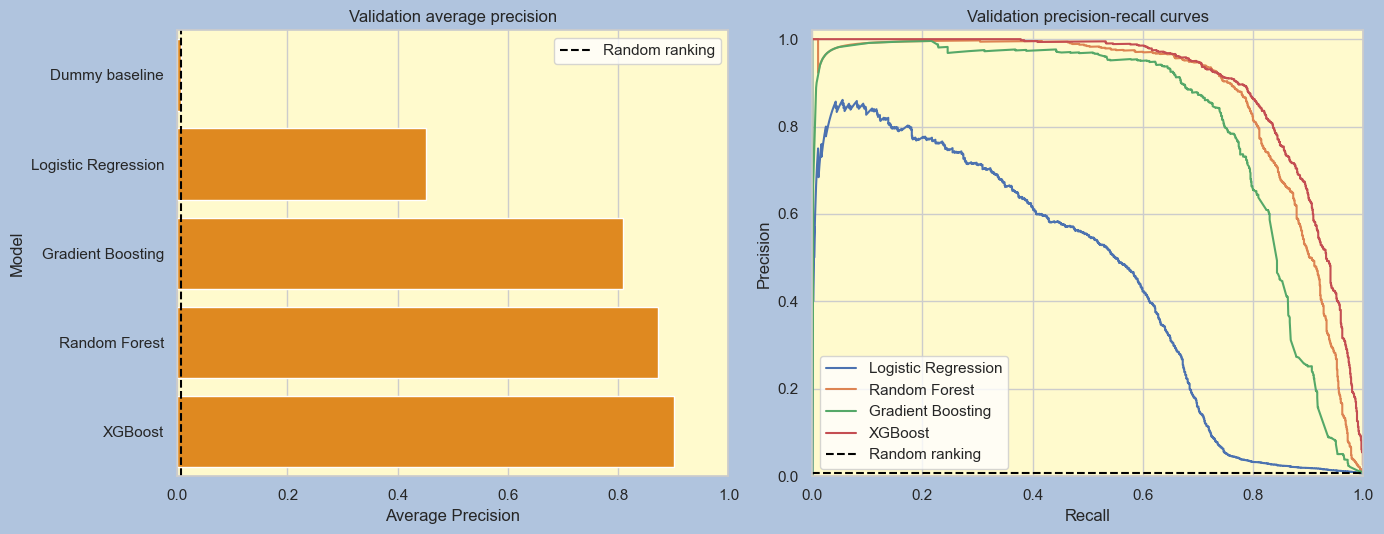

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='lightsteelblue')

plot_data = validation_results.sort_values("Average Precision")
sns.barplot(data=plot_data, x="Average Precision", y="Model", color="darkorange", ax=axes[0])
axes[0].axvline(y_validation.mean(), color="black", linestyle="--", label="Random ranking")
axes[0].set_title("Validation average precision")
axes[0].set_xlim(0, 1)
axes[0].set_facecolor('lemonchiffon')
axes[0].legend()

for model_name, probability in validation_probabilities.items():
    if model_name == "Dummy baseline":
        continue
    precision_values, recall_values, _ = precision_recall_curve(y_validation, probability)
    axes[1].plot(recall_values, precision_values, label=model_name)

axes[1].axhline(y_validation.mean(), color="black", linestyle="--", label="Random ranking")
axes[1].set_title("Validation precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].set_facecolor('lemonchiffon')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

Average precision is used to select the model because it focuses on the fraud class. Each model assigns a fraud probability to every transaction. By moving the probability threshold from high to low, we can measure the precision obtained as progressively more fraud cases are detected. Average precision summarises performance across all these possible thresholds, so the model can be selected before choosing a specific classification cutoff.

A high score means true fraud tends to appear near the top of the model’s ranking without too many legitimate transactions appearing alongside it. This is more informative than ROC AUC for this highly imbalanced dataset because ROC AUC can remain very high when the large number of non-fraud transactions dominates the false-positive rate.

The Dummy Classifier gives every transaction the same probability and therefore cannot rank one transaction above another. Its average precision is approximately the validation fraud rate of 0.0065, giving us a no-skill reference. XGBoost achieved the highest average precision of 0.9010, followed by Random Forest at 0.8724, meaning XGBoost produced the strongest fraud ranking on the later validation period.

An average precision of 0.9010 does not mean 90.10% accuracy or recall. It summarises ranking quality across every possible threshold. The final precision and recall can only be calculated after a specific threshold is selected.

## Checking whether cardholder history adds value

In [10]:
history_features = ["log_hours_since_previous", "amount_to_prior_mean"]
features_without_history = [
    feature for feature in model_features
    if feature not in history_features
]

xgboost_without_history = clone(candidate_models["XGBoost"])
xgboost_without_history.fit(
    X_training[features_without_history],
    y_training,
)
probability_without_history = xgboost_without_history.predict_proba(
    X_validation[features_without_history]
)[:, 1]

history_test = pd.DataFrame({
    "Feature set": ["Without cardholder history", "With cardholder history"],
    "Validation Average Precision": [
        average_precision_score(y_validation, probability_without_history),
        validation_results.loc[
            validation_results["Model"] == "XGBoost",
            "Average Precision",
        ].iloc[0],
    ],
})

history_test

,Feature set,Validation Average Precision
0,Without cardholder history,0.852404
1,With cardholder history,0.900979


The same XGBoost settings are fitted with and without `log_hours_since_previous` and `amount_to_prior_mean`, so the only difference is the cardholder-history information.

Adding these features increases validation average precision from 0.8524 to 0.9010, an improvement of 0.0486. This confirms that comparing a transaction with the cardholder’s earlier behaviour improves fraud ranking on later data, so we keep both history features in the final model.

## Refitting the selected model

The validation results are ordered by average precision, so the first row contains the best-performing model. In this case, XGBoost. We clone to create a new, unfitted copy with the same hyperparameters rather than reusing the model fitted during comparison. We then combine the original training and validation periods to give the final model more historical data to learn from while keeping the later threshold period separate.

We then split the data into:

- `X_refit` and `y_refit`, used to train the selected model
- `X_threshold` and `y_threshold`, used only to select the classification threshold
- `X_final_test` and `y_final_test`, kept for the final evaluation

> Note: The Logistic Regression section is included in the case it won the comparison. Its numerical features must be standardised using a scaler fitted only on the refit data. The tree-based models do not require scaling, so XGBoost uses the original feature values.

The selected model gets fitted from scratch using the combined training and validation periods. It then produces fraud probabilities for the threshold period. The threshold and final test labels are not used to train the model.

In [11]:
selected_model_name = validation_results.loc[0, "Model"]
selected_model = clone(candidate_models[selected_model_name])

refit_period = pd.concat([training_period, validation_period], ignore_index=True)
X_refit = refit_period[model_features]
y_refit = refit_period["is_fraud"]
X_threshold = threshold_period[model_features]
y_threshold = threshold_period["is_fraud"]
X_final_test = final_test_data[model_features]
y_final_test = final_test_data["is_fraud"]

if selected_model_name == "Logistic Regression":
    final_scaler = StandardScaler()
    X_refit_for_model = X_refit.astype("float32").copy()
    X_threshold_for_model = X_threshold.astype("float32").copy()
    X_final_test_for_model = X_final_test.astype("float32").copy()
    X_refit_for_model[numeric_features] = final_scaler.fit_transform(X_refit[numeric_features])
    X_threshold_for_model[numeric_features] = final_scaler.transform(X_threshold[numeric_features])
    X_final_test_for_model[numeric_features] = final_scaler.transform(X_final_test[numeric_features])
else:
    X_refit_for_model = X_refit
    X_threshold_for_model = X_threshold
    X_final_test_for_model = X_final_test

selected_model.fit(X_refit_for_model, y_refit)
threshold_probability = selected_model.predict_proba(X_threshold_for_model)[:, 1]

print("Selected model:", selected_model_name)

Selected model: XGBoost


## Choosing a fraud-focused threshold

In [12]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_threshold,
    threshold_probability,
)
precision_at_threshold = precision_values[:-1]
recall_at_threshold = recall_values[:-1]
f2_values = np.divide(
    5 * precision_at_threshold * recall_at_threshold,
    4 * precision_at_threshold + recall_at_threshold,
    out=np.zeros_like(precision_at_threshold),
    where=(4 * precision_at_threshold + recall_at_threshold) != 0,
)

best_threshold_position = np.argmax(f2_values)
operating_threshold = thresholds[best_threshold_position]
threshold_prediction = (threshold_probability >= operating_threshold).astype(int)

threshold_matrix = confusion_matrix(y_threshold, threshold_prediction)
threshold_tn, threshold_fp, threshold_fn, threshold_tp = threshold_matrix.ravel()

threshold_summary = pd.Series({
    "Probability threshold": operating_threshold,
    "Fraud caught": threshold_tp,
    "Fraud missed": threshold_fn,
    "False alerts": threshold_fp,
    "Precision": precision_score(y_threshold, threshold_prediction),
    "Recall": recall_score(y_threshold, threshold_prediction),
    "F2 score": fbeta_score(y_threshold, threshold_prediction, beta=2),
    "Percentage of transactions flagged": threshold_prediction.mean(),
})

threshold_summary.to_frame("Threshold-period result")

,Threshold-period result
Probability threshold,0.108937
Fraud caught,1035.000000
Fraud missed,128.000000
False alerts,507.000000
Precision,0.671206
Recall,0.889940
F2 score,0.835486
Percentage of transactions flagged,0.007749


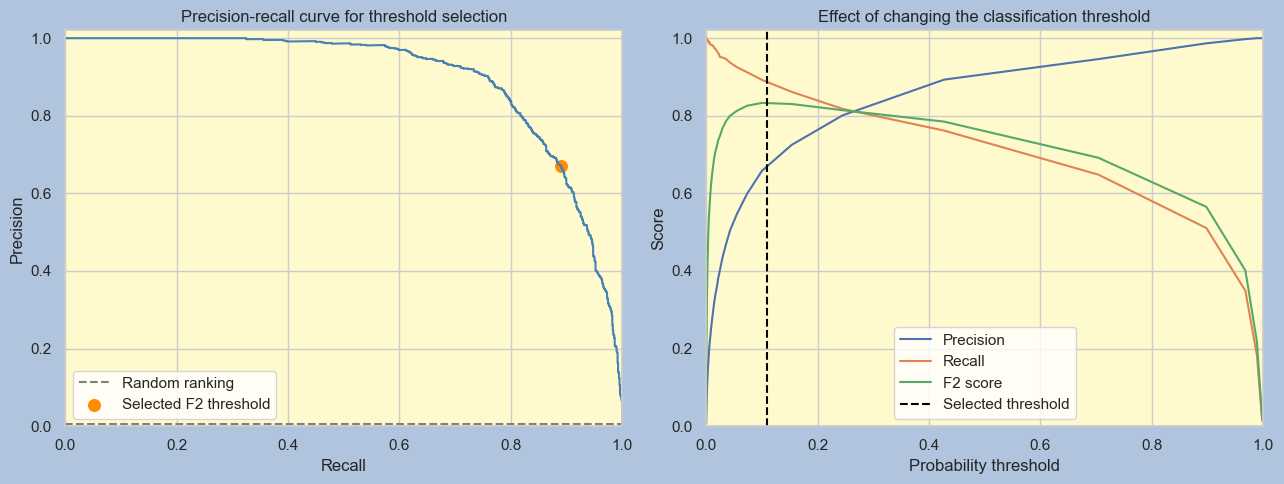

In [13]:
step = max(1, len(thresholds) // 1_000)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='lightsteelblue')
axes[0].plot(recall_values, precision_values, color="steelblue")
axes[0].scatter(
    recall_at_threshold[best_threshold_position],
    precision_at_threshold[best_threshold_position],
    color="darkorange",
    s=70,
    label="Selected F2 threshold",
)
axes[0].axhline(y_threshold.mean(), color="grey", linestyle="--", label="Random ranking")
axes[0].set_title("Precision-recall curve for threshold selection")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].set_facecolor('lemonchiffon')
axes[0].legend(loc="lower left")

axes[1].plot(thresholds[::step], precision_at_threshold[::step], label="Precision")
axes[1].plot(thresholds[::step], recall_at_threshold[::step], label="Recall")
axes[1].plot(thresholds[::step], f2_values[::step], label="F2 score")
axes[1].axvline(operating_threshold, color="black", linestyle="--", label="Selected threshold")
axes[1].set_title("Effect of changing the classification threshold")
axes[1].set_xlabel("Probability threshold")
axes[1].set_ylabel("Score")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].set_facecolor('lemonchiffon')
axes[1].legend()

plt.tight_layout()
plt.show()

A lower threshold catches more fraud but creates more false alerts, while a higher threshold reduces false alerts but misses more fraud. We test every possible threshold on the separate threshold selection period and choose the one with the highest F2 score, which gives more importance to recall than precision. 

The selected threshold is approximately 0.109. It catches 1,035 of the 1,163 fraud cases (89.0% recall), while 67.1% of its alerts are genuine fraud.

## Final evaluation on the supplied test data

In [14]:
final_probability = selected_model.predict_proba(X_final_test_for_model)[:, 1]
final_prediction = (final_probability >= operating_threshold).astype(int)

final_matrix = confusion_matrix(y_final_test, final_prediction)
final_tn, final_fp, final_fn, final_tp = final_matrix.ravel()

final_results = pd.Series({
    "Average Precision": average_precision_score(y_final_test, final_probability),
    "ROC AUC": roc_auc_score(y_final_test, final_probability),
    "Fraud caught": final_tp,
    "Fraud missed": final_fn,
    "False alerts": final_fp,
    "Precision": precision_score(y_final_test, final_prediction),
    "Recall": recall_score(y_final_test, final_prediction),
    "F1 score": f1_score(y_final_test, final_prediction),
    "F2 score": fbeta_score(y_final_test, final_prediction, beta=2),
    "Percentage of transactions flagged": final_prediction.mean(),
    "False alerts per 10,000 transactions": final_fp / len(y_final_test) * 10_000,
    "Fraud value recall": (
        test_metadata.loc[
            (y_final_test.to_numpy() == 1) & (final_prediction == 1),
            "amt",
        ].sum()
        / test_metadata.loc[y_final_test.to_numpy() == 1, "amt"].sum()
    ),
    "Accuracy": (final_tp + final_tn) / final_matrix.sum(),
})

final_results.to_frame("Final test result")

,Final test result
Average Precision,0.854237
ROC AUC,0.997118
Fraud caught,1848.000000
Fraud missed,297.000000
False alerts,1302.000000
Precision,0.586667
Recall,0.861538
F1 score,0.698017
F2 score,0.787724
Percentage of transactions flagged,0.005668


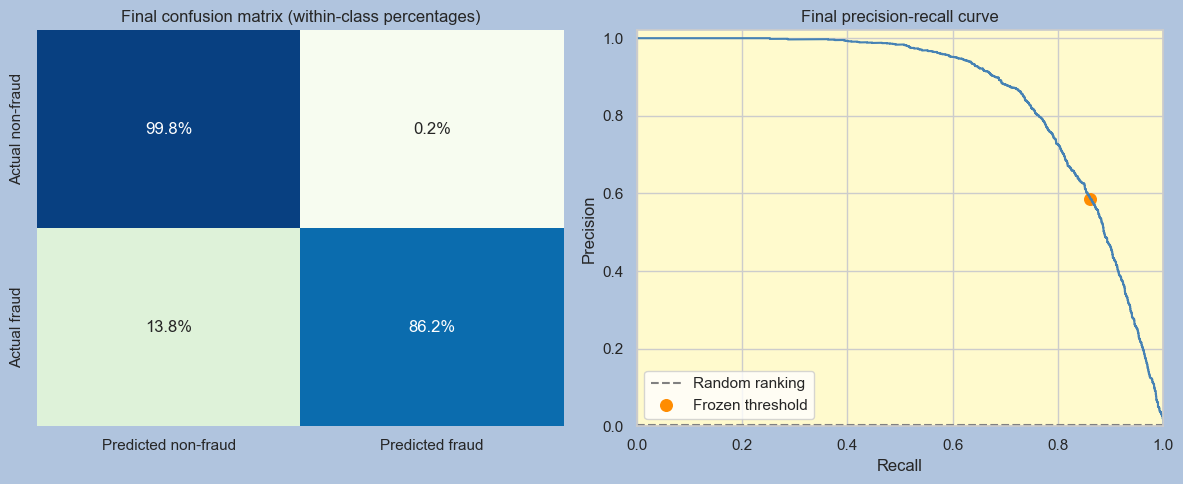

In [15]:
normalised_matrix = confusion_matrix(
    y_final_test,
    final_prediction,
    normalize="true",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='lightsteelblue')
sns.heatmap(
    normalised_matrix,
    annot=True,
    fmt=".1%",
    cmap='GnBu',
    cbar=False,
    xticklabels=["Predicted non-fraud", "Predicted fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"],
    ax=axes[0],
)
axes[0].set_title("Final confusion matrix (within-class percentages)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

final_precision_curve, final_recall_curve, _ = precision_recall_curve(
    y_final_test,
    final_probability,
)
axes[1].plot(final_recall_curve, final_precision_curve, color="steelblue")
axes[1].scatter(
    recall_score(y_final_test, final_prediction),
    precision_score(y_final_test, final_prediction),
    color="darkorange",
    s=70,
    label="Frozen threshold",
)
axes[1].axhline(y_final_test.mean(), color="grey", linestyle="--", label="Random ranking")
axes[1].set_title("Final precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].set_facecolor('lemonchiffon')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## Feature importance

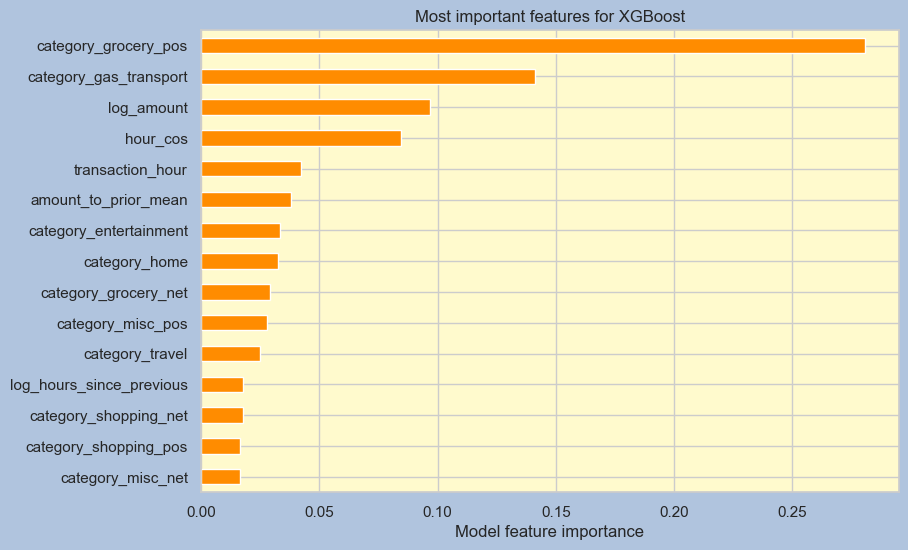

In [16]:
if hasattr(selected_model, "feature_importances_"):
    importance = pd.Series(
        selected_model.feature_importances_,
        index=model_features,
    )
else:
    importance = pd.Series(
        np.abs(selected_model.coef_[0]),
        index=model_features,
    )

top_importance = importance.nlargest(15).sort_values()

plt.figure(figsize=(9, 6), facecolor='lightsteelblue')
top_importance.plot(kind="barh", color="darkorange")
plt.title(f"Most important features for {selected_model_name}")
plt.xlabel("Model feature importance")
plt.ylabel("")
plt.gca().set_facecolor('lemonchiffon')
plt.show()

Merchant category, transaction amount and time of day have the highest XGBoost feature importance, which agrees with the main patterns found during the EDA. `amount_to_prior_mean` also appears among the leading features, while the earlier with-and-without-history comparison supports keeping the two history variables together. These values show which variables create useful splits across the fitted trees, but they do not show the direction of an effect or explain every individual prediction.

## Error analysis

In [17]:
# Start with the transaction details kept from the test data
test_evaluation = test_metadata.copy()

# Add the true result, the model's decision and its predicted probability
test_evaluation["Actual_fraud"] = y_final_test.to_numpy()
test_evaluation["Predicted_fraud"] = final_prediction
test_evaluation["Fraud_probability"] = final_probability

# Mark fraud transactions which the model correctly caught
test_evaluation["True_positive"] = (
    (test_evaluation["Actual_fraud"] == 1)
    & (test_evaluation["Predicted_fraud"] == 1)
).astype(int)

# Mark genuine transactions which the model incorrectly flagged
test_evaluation["False_positive"] = (
    (test_evaluation["Actual_fraud"] == 0)
    & (test_evaluation["Predicted_fraud"] == 1)
).astype(int)

# Summarise the model's performance within each merchant category
category_errors = (
    test_evaluation.groupby("category")
    .agg(
        Transactions=("Actual_fraud", "size"),
        Fraud_cases=("Actual_fraud", "sum"),
        Fraud_caught=("True_positive", "sum"),
        False_alerts=("False_positive", "sum"),
    )
    .reset_index()
)

# Calculate the percentage of fraud cases caught in each category
category_errors["Fraud_recall"] = (
    category_errors["Fraud_caught"] / category_errors["Fraud_cases"]
)

# False alerts per 1,000 transactions so categories are comparable
category_errors["False_alerts_per_1000"] = (
    category_errors["False_alerts"] / category_errors["Transactions"] * 1_000
)

category_errors

,category,Transactions,Fraud_cases,Fraud_caught,False_alerts,Fraud_recall,False_alerts_per_1000
0,entertainment,40104,59,55,40,0.932203,0.997407
1,food_dining,39268,54,19,55,0.351852,1.400632
2,gas_transport,56370,154,154,24,1.000000,0.425758
3,grocery_net,19426,41,30,115,0.731707,5.919901
4,grocery_pos,52553,485,484,18,0.997938,0.342511
5,health_fitness,36674,52,17,31,0.326923,0.845285
6,home,52345,67,40,85,0.597015,1.623842
7,kids_pets,48692,65,29,83,0.446154,1.704592
8,misc_net,27367,267,254,126,0.951311,4.604085
9,misc_pos,34574,72,38,59,0.527778,1.706485


The model performs differently across merchant categories. 
It catches almost all fraud in gas_transport and grocery_pos, and more than 92% in several online and shopping categories. 

Recall is much lower for travel, health_fitness and food_dining, where only around 30–35% of fraud is detected. 

False-alert rates per 1,000 transactions are highest in shopping_net, grocery_net and shopping_pos. 

This shows why the overall result should be supported by category-level checks, although categories with relatively few fraud cases should be interpreted more cautiously.

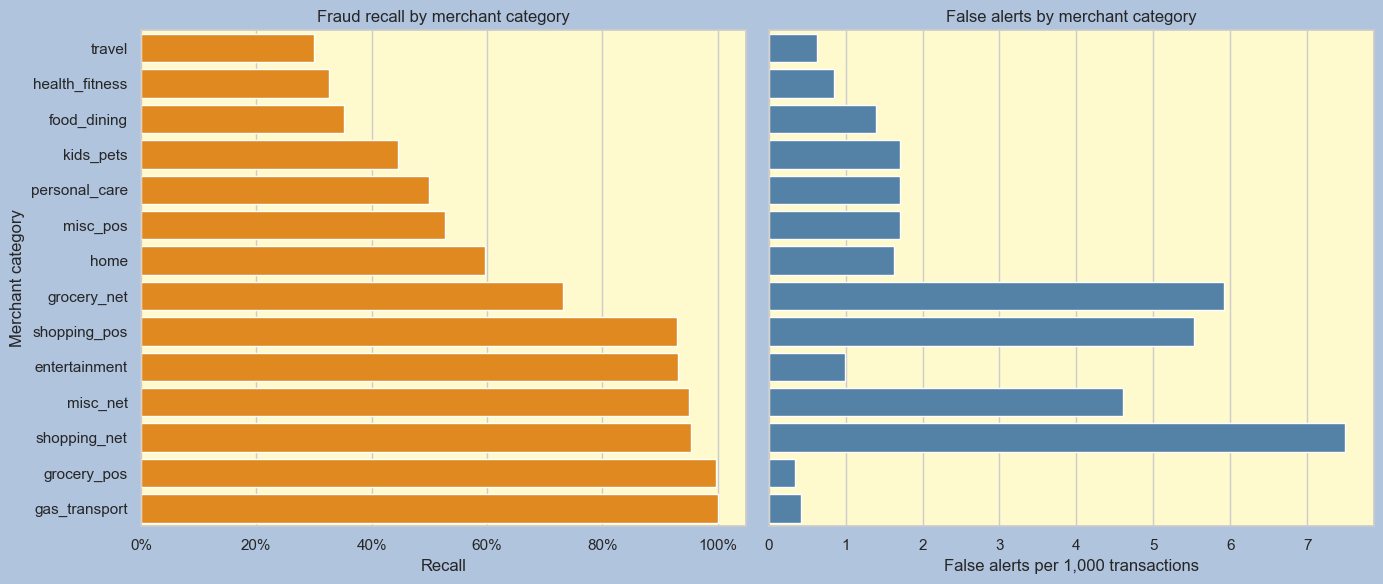

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, facecolor = 'lightsteelblue')
category_plot = category_errors.sort_values("Fraud_recall")

sns.barplot(data=category_plot, x="Fraud_recall", y="category", color="darkorange", ax=axes[0])
axes[0].set_title("Fraud recall by merchant category")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Merchant category")
axes[0].xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
axes[0].set_facecolor('lemonchiffon')

sns.barplot(data=category_plot, x="False_alerts_per_1000", y="category", color="steelblue", ax=axes[1])
axes[1].set_title("False alerts by merchant category")
axes[1].set_xlabel("False alerts per 1,000 transactions")
axes[1].set_ylabel("")
axes[1].set_facecolor('lemonchiffon')

plt.tight_layout()
plt.show()

The model catches almost all fraud in gas_transport and grocery_pos while producing fewer than 0.5 false alerts per 1,000 transactions. 

shopping_net also has high recall, but this comes with the highest false-alert rate. 

In contrast, travel, health_fitness and food_dining produce relatively few false alerts but miss most of their fraud cases. This shows that the overall model result hides important differences between categories.

In [19]:
# Check whether model performance differs between the recorded gender groups
# Gender was not used to train the model
gender_check = (
    test_evaluation.groupby("gender")
    .agg(
        Transactions=("Actual_fraud", "size"),
        Fraud_cases=("Actual_fraud", "sum"),
        Fraud_caught=("True_positive", "sum"),
        False_alerts=("False_positive", "sum"),
    )
)

# Calculate fraud recall and false alerts for each group
gender_check["Fraud_recall"] = gender_check["Fraud_caught"] / gender_check["Fraud_cases"]
gender_check["False_alerts_per_1000"] = gender_check["False_alerts"] / gender_check["Transactions"] * 1_000

display(gender_check)

# Check whether each test card appeared in the training data
# This is only an evaluation check: the card number is not a model input
test_evaluation["Card_seen_in_training_data"] = test_evaluation["cc_num"].isin(
    train_df["cc_num"].unique()
)

# Compare results for previously seen and unseen cards
card_history_check = (
    test_evaluation.groupby("Card_seen_in_training_data")
    .agg(
        Transactions=("Actual_fraud", "size"),
        Fraud_cases=("Actual_fraud", "sum"),
        Fraud_caught=("True_positive", "sum"),
        False_alerts=("False_positive", "sum"),
    )
)

# Calculate the fraud rate and fraud recall within each group
card_history_check["Fraud_rate"] = card_history_check["Fraud_cases"] / card_history_check["Transactions"]
card_history_check["Fraud_recall"] = card_history_check["Fraud_caught"] / card_history_check["Fraud_cases"]

print("Seen card check:")
display(card_history_check)

# Select fraud transactions which the model incorrectly classified as non-fraud
missed_fraud = (
    test_evaluation[
        (test_evaluation["Actual_fraud"] == 1)
        & (test_evaluation["Predicted_fraud"] == 0)
    ][["trans_date_trans_time", "category", "amt", "Fraud_probability"]]
    .sort_values("amt", ascending=False) # Display the ten highest-value missed fraud cases
    .head(10)
)

print("Highest-value missed fraud transactions:")
missed_fraud

,Transactions,Fraud_cases,Fraud_caught,False_alerts,Fraud_recall,False_alerts_per_1000
gender,,,,,,
F,304886,1164,932,856,0.800687,2.807607
M,250833,981,916,446,0.933741,1.778075


Seen card check:


,Transactions,Fraud_cases,Fraud_caught,False_alerts,Fraud_rate,Fraud_recall
Card_seen_in_training_data,,,,,,
False,163,163,158,0,1.000000,0.969325
True,555556,1982,1690,1302,0.003568,0.852674


Highest-value missed fraud transactions:


,trans_date_trans_time,category,amt,Fraud_probability
327216,2020-10-24 20:25:22,shopping_net,1140.88,0.064563
401045,2020-11-25 16:05:03,shopping_net,1133.52,0.067117
29593,2020-06-30 21:38:41,shopping_net,1123.95,0.099040
298808,2020-10-12 03:37:33,shopping_pos,1111.57,0.074319
432545,2020-12-05 01:44:23,shopping_pos,1107.65,0.099376
189658,2020-08-26 13:17:40,shopping_net,1104.35,0.019238
23015,2020-06-29 06:55:59,shopping_net,1071.19,0.051498
284199,2020-10-05 14:57:29,shopping_net,1061.02,0.057560
178388,2020-08-23 07:00:23,shopping_net,1054.16,0.046466
47434,2020-07-07 09:49:26,shopping_net,1041.39,0.069699


The subgroup checks show that performance is not completely uniform. 

Fraud recall is lower for female cardholders, even though gender is not included as a model feature. 

The seen-card check also shows an unusual dataset pattern: all transactions from unseen cards are fraudulent. This means the unseen-card group is not a realistic test of new-card performance. The earlier with-and-without-history comparison is the direct test of whether the history features add value. 

Finally, several high-value shopping frauds fall below the selected threshold. F2 does not include transaction value, so the selected threshold does not guarantee that the highest-value fraud cases will be caught.

## Conclusion

Among models tested, XGBoost produced the strongest fraud ranking on the validation period. Its average precision was 0.9010, compared with 0.8724 for Random Forest and 0.4521 for Logistic Regression. The Dummy Classifier result of 0.0065 gives us the no skill reference.

Adding the two cardholder history features increased XGBoost validation average precision from 0.8524 to 0.9010. This supports comparing each transaction with the cardholder's earlier behaviour rather than relying only on the transaction itself.

We selected the classification threshold on a separate period and then applied it unchanged to the final test data. Final test average precision was 0.8542, which is lower than the validation result of 0.9010. At the selected threshold, the model caught 1,848 of the 2,145 fraud cases, giving 86.15% recall, 58.67% precision and an F2 score of 0.7877. It missed 297 fraud cases, produced 1,302 false alerts and captured 94.34% of the total fraudulent transaction value.

The overall scores hide weaker areas. Recall falls to 30.00% for travel, 32.69% for health and fitness and 35.19% for food dining. Recall is also 80.07% for female cardholders compared with 93.37% for male cardholders, even though gender is not used by the model. These checks show why category and subgroup results need to be considered alongside the overall scores.